## 1. What this notebook computes

Notebooks 07a, 07b and 07c USE the Euler-Lagrange equation: they take a Lagrangian
and compute the expression $\partial L/\partial q - \frac{d}{dt}\,\partial L /
\partial\dot q$. This notebook shows where that expression comes from, with nothing
more than one-variable calculus and a computer that checks every step. It

- computes, exactly, the **action** (the time integral of the Lagrangian) of the
  true motion of an oscillator and of two wrong motions with the same end points,
  and of every motion changed by a small amount $\epsilon$ times a fixed shape;
  only the true motion has an action whose slope in $\epsilon$ is zero;
- shows that the true motion makes the action a minimum for short times and only
  stationary (a saddle) for long times;
- checks the integration by parts that turns the slope into the integral of the
  **Euler-Lagrange expression** times the shape, and shows the boundary term that
  appears when the shape does not vanish at the ends;
- illustrates the **fundamental lemma** with narrow bumps: a function whose
  integral against every bump is zero must be zero;
- writes the action on a grid of times, as a computer would, shows that its
  derivatives are the Euler-Lagrange expression on the grid, solves the grid
  equations and measures the error, which falls like the square of the step;
- checks that the energy is constant on the true motion and only there;
- checks that adding a total derivative to a Lagrangian changes no equation;
- derives the equations of two **first-order** Lagrangians, of the kind the fields
  of this book have: two real variables, and one complex variable $\psi$ varied
  together with its conjugate $\psi^*$ as if they were independent;
- derives the field equation of a field of one space coordinate and time, and of
  a field of one EXTRA time and time, and shows that the extra time turns
  oscillation into exponential growth, with the growth rate of the Revision record.

Every result is checked by a line that starts with PASS; the last line counts the
checks. Eight figures are drawn and saved.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 07d (The action principle and the Euler-Lagrange equation) is the file
`Revision/textbook/notebooks/07d_action_principle.ipynb` of the repository Dirac_claude.
It shows, for a reader who knows one-variable calculus, where the Euler-Lagrange equation
comes from: it computes exactly the action of the true path and of two wrong paths of an
oscillator and of their small variations, shows that only the true path makes the action
stationary, checks the integration by parts, the fundamental lemma with narrow bumps, the
action on a grid of times and its second-order convergence, the conserved energy, that a
total derivative changes no equation, the first-order Lagrangians of a real pair and of
one complex variable, and the field equation of a field of a space direction or of an
extra time with time; it reproduces the growth rate of the Revision record for an
extra-time momentum, and draws eight teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 07d_action_principle.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 07d_action_principle.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
07d_action_principle.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/07d.captions.json`
- `Revision/textbook/figures/07d_1_action_versus_epsilon.png`
- `Revision/textbook/figures/07d_2_paths_and_residuals.png`
- `Revision/textbook/figures/07d_3_bump_lemma.png`
- `Revision/textbook/figures/07d_4_action_on_a_grid.png`
- `Revision/textbook/figures/07d_5_energy_along_paths.png`
- `Revision/textbook/figures/07d_6_first_order_rotation.png`
- `Revision/textbook/figures/07d_7_space_and_extra_time.png`
- `Revision/textbook/figures/07d_8_dispersion.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 8 figure files of this notebook exist
    ALL 30 CHECKS PASSED (notebook 07d)

and the notebook must show 8 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/07d_action_principle.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "ValueError: ... is not a passing check of Revision/theory/reports/...": the Revision
  record files of your copy of the repository differ from the committed ones; restore
  them with the command below (run in the repository folder) and run the notebook again.

      git restore Revision/theory/reports Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 07d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 07d (The action principle and the Euler-Lagrange equation) is the file
# Revision/textbook/notebooks/07d_action_principle.ipynb of the repository Dirac_claude.
# It shows, for a reader who knows one-variable calculus, where the Euler-Lagrange
# equation comes from: it computes exactly the action of the true path and of two wrong
# paths of an oscillator and of their small variations, shows that only the true path
# makes the action stationary, checks the integration by parts, the fundamental lemma
# with narrow bumps, the action on a grid of times and its second-order convergence, the
# conserved energy, that a total derivative changes no equation, the first-order
# Lagrangians of a real pair and of one complex variable, and the field equation of a
# field of a space direction or of an extra time with time; it reproduces the growth rate
# of the Revision record for an extra-time momentum, and draws eight teaching plots. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 07d_action_principle.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 07d_action_principle.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 07d_action_principle.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/07d.captions.json
# - Revision/textbook/figures/07d_1_action_versus_epsilon.png
# - Revision/textbook/figures/07d_2_paths_and_residuals.png
# - Revision/textbook/figures/07d_3_bump_lemma.png
# - Revision/textbook/figures/07d_4_action_on_a_grid.png
# - Revision/textbook/figures/07d_5_energy_along_paths.png
# - Revision/textbook/figures/07d_6_first_order_rotation.png
# - Revision/textbook/figures/07d_7_space_and_extra_time.png
# - Revision/textbook/figures/07d_8_dispersion.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 8 figure files of this notebook exist
#     ALL 30 CHECKS PASSED (notebook 07d)
#
# and the notebook must show 8 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/07d_action_principle.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "ValueError: ... is not a passing check of Revision/theory/reports/...": the Revision
#   record files of your copy of the repository differ from the committed ones; restore
#   them with the command below (run in the repository folder) and run the notebook
#   again.
#     git restore Revision/theory/reports Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "07d"  # this notebook: chapter 07, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 07d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Path** (or motion): a function $q(t)$ that gives the position $q$ of a particle
  on a line at every time $t$ between a start time and an end time. Here the times
  run from $0$ to $T$. Its **velocity** is $\dot q = dq/dt$, its **acceleration**
  $\ddot q = d^2q/dt^2$.
- **Lagrangian** $L(q, \dot q)$: a function of the position and the velocity; for
  the oscillator of this notebook $L = \frac12\dot q^2 - \frac12\omega^2q^2$, the
  kinetic energy minus the potential energy (mass 1, angular frequency $\omega$).
- **Action** $S[q] = \int_0^T L(q(t), \dot q(t))\,dt$: one number for a whole
  path. The square brackets say that $S$ depends on the whole function $q$; such a
  rule (a function in, a number out) is called a **functional**.
- **Variation**: a shape $\xi(t)$ with $\xi(0) = \xi(T) = 0$; the varied path is
  $q + \epsilon\xi$ with a small number $\epsilon$. The **first variation** is the
  slope $dS[q + \epsilon\xi]/d\epsilon$ at $\epsilon = 0$.
- **Stationary path**: a path whose first variation is zero for every variation.
  The **principle of stationary action** says that the true motion is stationary.
- **Euler-Lagrange expression** $E(t) = \partial L/\partial q - \frac{d}{dt}\,
  \partial L/\partial\dot q$, and the **Euler-Lagrange equation** $E = 0$. In
  $\partial L/\partial q$ the velocity is held fixed, in $\partial L/\partial\dot q$
  the position.
- **Integration by parts**: the product rule $\frac{d}{dt}(fg) = \dot f g +
  f\dot g$ integrated from $0$ to $T$: $\int_0^T f\dot g\,dt = [fg]_0^T -
  \int_0^T \dot f g\,dt$, where $[fg]_0^T = f(T)g(T) - f(0)g(0)$ is the
  **boundary term**.
- **Bump**: a smooth shape that is positive on a small interval and zero outside.
- **Grid**: the equally spaced times $t_n = nh$, $n = 0, 1, \dots, N$, with step
  $h = T/N$. **Order of convergence**: the power $p$ in error $\approx$ constant
  $\times\,h^p$.
- **Energy** $H = \dot q\,\partial L/\partial\dot q - L$; for the oscillator $H =
  \frac12\dot q^2 + \frac12\omega^2q^2$.
- **Total derivative**: $\frac{d}{dt}F(q(t), t)$ for some function $F$.
- **First-order Lagrangian**: a Lagrangian that contains the velocities only to
  the first power, like the Lagrangians of the fields of this book.
- **Field**: a function of several coordinates, here $\phi(x_1, x_4)$ or
  $\phi(x_5, x_4)$, with the author's names: $x_1$ a direction of 3-space, $x_4$
  the time, $x_5$ one of the three extra times. **Lagrangian density**: the
  Lagrangian of a field, integrated over all its coordinates.
- **Plane wave**: a field such as $\cos(kx_1)\cos(\omega x_4)$, with **wave number**
  $k$ and angular frequency $\omega$. **Dispersion relation**: the equation that
  links $\omega$ to $k$.

## 4. The physical and mathematical situation

**The principle.** Among all paths with the same end points, $q(0) = q_A$ and
$q(T) = q_B$, the particle follows one for which the action does not change to
first order when the path is changed a little: for every variation $\xi$,

$$\frac{d}{d\epsilon}S[q + \epsilon\xi]\Big|_{\epsilon = 0} = 0 .$$

**From the principle to the equation, line by line.**

$$\frac{d}{d\epsilon}S[q + \epsilon\xi]\Big|_{\epsilon=0} = \int_0^T\Big(
\frac{\partial L}{\partial q}\,\xi + \frac{\partial L}{\partial\dot q}\,\dot\xi
\Big)dt$$

This first line differentiates under the integral sign with the chain rule: $L$
depends on $\epsilon$ through its first argument $q + \epsilon\xi$ (derivative
$\xi$) and through its second argument $\dot q + \epsilon\dot\xi$ (derivative
$\dot\xi$).

$$= \int_0^T\frac{\partial L}{\partial q}\,\xi\,dt + \Big[\frac{\partial L}
{\partial\dot q}\,\xi\Big]_0^T - \int_0^T\frac{d}{dt}\Big(\frac{\partial L}
{\partial\dot q}\Big)\xi\,dt$$

The second line integrates the second term by parts with $f = \partial L/\partial
\dot q$ and $g = \xi$.

$$= \int_0^T E(t)\,\xi(t)\,dt,\qquad E = \frac{\partial L}{\partial q} -
\frac{d}{dt}\frac{\partial L}{\partial\dot q} .$$

The third line drops the boundary term, which is zero because $\xi(0) = \xi(T) =
0$, and collects the two integrals. Finally the **fundamental lemma**: if a
continuous $E$ had $E(t_0) > 0$ at some time $t_0$, it would be positive on a small
interval around $t_0$, and a bump $\xi$ on that interval would give $\int E\xi\,dt
> 0$; the same with signs reversed for $E(t_0) < 0$. So the true path satisfies
the **Euler-Lagrange equation** $E(t) = 0$ at every time. For the oscillator,
$\partial L/\partial q = -\omega^2q$ and $\partial L/\partial\dot q = \dot q$, so
$E = -\omega^2q - \ddot q$ and the equation is $\ddot q = -\omega^2q$.

**The example of this notebook.** $\omega = 1$, $T = 1$, $q(0) = 0$, $q(1) = 1$.
The true path is $q(t) = \sin t/\sin 1$ (it solves $\ddot q = -q$ and has the right
end values). Two wrong paths with the same end values: the straight line $q = t$
and the parabola $q = t^2$. Variations: $\xi_n(t) = \sin(n\pi t)$, $n = 1, 2, 3$,
which vanish at $t = 0$ and $t = 1$.

**Fields.** For a field $\phi$ of several coordinates the action is the integral of
a Lagrangian density over all of them, the variation $\xi$ vanishes on the
boundary of the region, and the same three lines give one derivative term for each
coordinate: $E = \partial L/\partial\phi - \sum_\mu \frac{\partial}{\partial
x_\mu}\,\partial L/\partial(\partial_\mu\phi)$. This is the expression that
Notebook 07b computes for the 16 components of the fields of this book in the
author's metric (with left derivatives for anticommuting components, Notebook 07a).

## 5. The action of the true path and of two wrong paths

The next cell imports the packages, wraps the set-up cell's `check` so that a PASS
line and the line "reproduces ..." that may follow it are printed by one single
`print` call (Jupyter may deliver two separate prints in two pieces, and the
book's tools must see the two lines together), and defines the helper
`reproduces`, which makes sure that a Revision report contains a check with the
verdict PASS before a PASS line names it.

Then it computes, with exact computer algebra (sympy), the action of $q +
\epsilon\xi_n$ for each of the three paths and $n = 1, 2, 3$. Since $L$ is a
polynomial of degree 2 in $q$ and $\dot q$, the action is a polynomial of degree 2
in $\epsilon$:

$$S[q + \epsilon\xi] = S_0 + S_1\,\epsilon + S_2\,\epsilon^2 .$$

$S_1$ is the first variation (the slope at $\epsilon = 0$). The cell prints $S_1$
for every path and every $n$, exactly and as a decimal number.

In [2]:
import contextlib  # redirect printed text into a buffer
import io  # an in-memory text file (the buffer)
import re  # regular expressions: read a formula from a check's detail text

import numpy as np  # arrays of numbers
import sympy as sp  # exact algebra with symbols

check_of_the_setup = check  # the helper check of the set-up cell


def check(condition, name, record=None):
    """The set-up cell's check, with its PASS line and its "reproduces" line
    printed by ONE print call, so that Jupyter delivers them together."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # collect what check prints
        check_of_the_setup(condition, name, record)
    print(buffer.getvalue(), end="")  # and print it in one piece


def revision_check(report, name):
    """The check called name of a Revision report (a JSON file): its dictionary
    (name, verdict, detail); stops if it is missing or its verdict is not PASS."""
    data = json.loads(repository_file(report).read_text(encoding="utf-8"))
    found = [item for item in data["checks"] if item["name"] == name]
    if len(found) != 1 or found[0]["verdict"].upper() != "PASS":
        raise ValueError(f"{name} is not a passing check of {report}")
    return found[0]


def reproduces(report, name):
    """The text "<report>, check <name>" after making sure the check passes."""
    revision_check(report, name)
    return f"{report}, check {name}"


t, eps = sp.symbols("t epsilon", real=True)  # the time and the size of the change
omega, T_end = sp.Integer(1), sp.Integer(1)  # omega = 1 and the end time T = 1


def lagrangian(q, q_dot):
    """The oscillator: kinetic energy minus potential energy."""
    return q_dot**2 / 2 - omega**2 * q**2 / 2


PATHS = {"true path": sp.sin(t) / sp.sin(1), "line": t, "parabola": t**2}
SHAPES = {n: sp.sin(n * sp.pi * t) for n in (1, 2, 3)}  # xi_n, zero at t = 0, 1


def action_polynomial(path, shape):
    """S[path + eps shape] as a polynomial in eps (exact)."""
    varied = path + eps * shape
    integrand = sp.expand(lagrangian(varied, sp.diff(varied, t)))
    return sp.Poly(sp.integrate(integrand, (t, 0, T_end)), eps)


S1 = {}  # the first variations, S1[(path name, n)]
S2 = {}  # the coefficients of eps^2
for name, path in PATHS.items():
    for n, shape in SHAPES.items():
        polynomial = action_polynomial(path, shape)
        S1[(name, n)] = sp.simplify(polynomial.coeff_monomial(eps))
        S2[(name, n)] = sp.simplify(polynomial.coeff_monomial(eps**2))
        say(f"{name:9s} n = {n}: S1 = {S1[(name, n)]} = "
            f"{float(S1[(name, n)]):+.6f}")

true path n = 1: S1 = 0 = +0.000000
true path n = 2: S1 = 0 = +0.000000
true path n = 3: S1 = 0 = +0.000000
line      n = 1: S1 = -1/pi = -0.318310
line      n = 2: S1 = 1/(2*pi) = +0.159155
line      n = 3: S1 = -1/(3*pi) = -0.106103
parabola  n = 1: S1 = -5/pi + 4/pi**3 = -1.462543
parabola  n = 2: S1 = 1/(2*pi) = +0.159155
parabola  n = 3: S1 = (4 - 45*pi**2)/(27*pi**3) = -0.525738


The next cell checks the two facts the table shows: for the true path the first
variation is exactly zero for all three shapes, for the two wrong paths it is not.
It also checks that the coefficient $S_2$ does not depend on the path: $S_2 =
\int_0^T(\frac12\dot\xi^2 - \frac12\omega^2\xi^2)\,dt$ is the action of the shape
itself, because the terms of $L$ that are quadratic in $\epsilon$ contain only
$\xi$.

In [3]:
check(all(S1[("true path", n)] == 0 for n in SHAPES),
      "the true path: the first variation is exactly 0 for xi_1, xi_2, xi_3")
check(all(S1[(name, n)] != 0 for name in ("line", "parabola") for n in SHAPES),
      "the line and the parabola: the first variation is not 0")
check(all(S2[(name, n)] == S2[("true path", n)] for name in PATHS for n in SHAPES),
      "the coefficient of eps^2 is the same for every path")
for n in SHAPES:
    coefficient = S2[("true path", n)]  # the same for every path
    report(f"S2 for xi_{n}", f"{coefficient} = {float(coefficient):.6f}")

PASS the true path: the first variation is exactly 0 for xi_1, xi_2, xi_3
PASS the line and the parabola: the first variation is not 0
PASS the coefficient of eps^2 is the same for every path
RESULT S2 for xi_1 = -1/4 + pi**2/4 = 2.217401
RESULT S2 for xi_2 = -1/4 + pi**2 = 9.619604
RESULT S2 for xi_3 = -1/4 + 9*pi**2/4 = 21.956610


## 6. A minimum, or only stationary?

For the shape $\xi_1 = \sin(\pi t/T)$ on an interval of general length $T$, the
coefficient $S_2$ is, line by line,

$$S_2 = \int_0^T\Big(\frac{\pi^2}{2T^2}\cos^2\frac{\pi t}{T} - \frac{\omega^2}{2}
\sin^2\frac{\pi t}{T}\Big)dt = \frac{\pi^2}{2T^2}\cdot\frac{T}{2} - \frac{\omega^2}
{2}\cdot\frac{T}{2} = \frac{T}{4}\Big(\frac{\pi^2}{T^2} - \omega^2\Big).$$

The first equality inserts $\dot\xi_1 = (\pi/T)\cos(\pi t/T)$. The second uses
$\cos^2 x = \frac12(1 + \cos 2x)$ and $\sin^2 x = \frac12(1 - \cos 2x)$: the interval
from 0 to $T$ is one full period of $\cos(2\pi t/T)$, whose integral over it is 0,
so $\cos^2(\pi t/T)$ and $\sin^2(\pi t/T)$ each integrate to $T/2$. The third
collects. So $S_2 > 0$ for $T < \pi/\omega$: then the true path is a MINIMUM of the
action along this direction. For $T > \pi/\omega$ the coefficient is negative: the
true path is still stationary ($S_1 = 0$), but the action is a maximum along
$\xi_1$ and a minimum along faster shapes, a saddle. This is why the principle is
called the principle of STATIONARY action, not of least action. The next cell
checks the formula with $T$ as a symbol, then draws Figure 1.

S2(T) = (-T**2 + pi**2)/(4*T)
PASS S2 = (T/4)(pi^2/T^2 - omega^2) for the shape xi_1 on (0, T)
PASS S2 > 0 for T = 1 (a minimum), S2 < 0 for T = 4 > pi (a saddle)


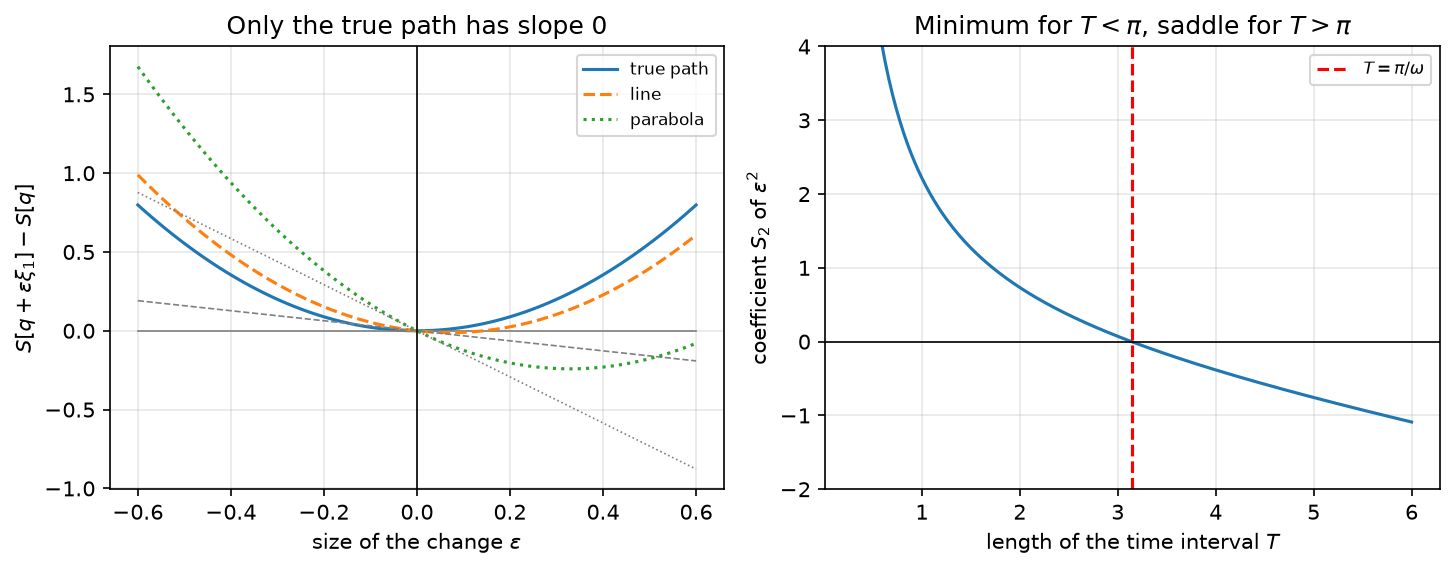

Figure 07d.1 saved as Revision/textbook/figures/07d_1_action_versus_epsilon.png


In [4]:
T = sp.Symbol("T", positive=True)
xi_T = sp.sin(sp.pi * t / T)  # the shape xi_1 on the interval from 0 to T
S2_general = sp.integrate(sp.diff(xi_T, t) ** 2 / 2 - omega**2 * xi_T**2 / 2,
                          (t, 0, T))
say(f"S2(T) = {sp.simplify(S2_general)}")
check(sp.simplify(S2_general - T / 4 * (sp.pi**2 / T**2 - omega**2)) == 0,
      "S2 = (T/4)(pi^2/T^2 - omega^2) for the shape xi_1 on (0, T)")
check(S2_general.subs(T, 1) > 0 and S2_general.subs(T, 4) < 0,
      "S2 > 0 for T = 1 (a minimum), S2 < 0 for T = 4 > pi (a saddle)")

epsilons = np.linspace(-0.6, 0.6, 121)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
for name, style in (("true path", "-"), ("line", "--"), ("parabola", ":")):
    polynomial = action_polynomial(PATHS[name], SHAPES[1])
    values = sp.lambdify(eps, polynomial.as_expr() - polynomial.coeff_monomial(1))
    left.plot(epsilons, values(epsilons), style, label=name)
    slope = float(S1[(name, 1)])
    left.plot(epsilons, slope * epsilons, style, color="grey", linewidth=0.8)
left.axvline(0.0, color="black", linewidth=0.8)
left.set_xlabel("size of the change $\\epsilon$")
left.set_ylabel("$S[q + \\epsilon\\xi_1] - S[q]$")
left.set_title("Only the true path has slope 0")
left.legend(fontsize=8)
lengths = np.linspace(0.3, 6.0, 300)
S2_values = sp.lambdify(T, S2_general)(lengths)
right.plot(lengths, S2_values)
right.axhline(0.0, color="black", linewidth=0.8)
right.axvline(np.pi, color="red", linestyle="--", label="$T = \\pi/\\omega$")
right.set_ylim(-2.0, 4.0)
right.set_xlabel("length of the time interval $T$")
right.set_ylabel("coefficient $S_2$ of $\\epsilon^2$")
right.set_title("Minimum for $T < \\pi$, saddle for $T > \\pi$")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "action_versus_epsilon",
            "Left: the change of the action of the oscillator ($\\omega = 1$, from "
            "$t = 0$ to $1$, end values 0 and 1) when a path $q$ is replaced by "
            "$q + \\epsilon\\xi_1$, against the size $\\epsilon$ of the change, for "
            "the true path "
            "$\\sin t/\\sin 1$ (solid) and the wrong paths $t$ (dashed) and $t^2$ "
            "(dotted), with the shape $\\xi_1 = \\sin\\pi t$; the thin grey lines "
            "are the tangents at $\\epsilon = 0$. Only the true path has a "
            "horizontal tangent: its first variation is zero. Right: the "
            "coefficient $S_2 = (T/4)(\\pi^2/T^2 - \\omega^2)$ of $\\epsilon^2$ "
            "against the length $T$ of the interval; it changes sign at $T = "
            "\\pi/\\omega$ (dashed red), where the minimum becomes a saddle.")

## 7. The first variation is the integral of $E$ times the shape

The derivation of section 4 says $S_1 = \int_0^1 E\,\xi\,dt$ when $\xi$ vanishes at
both ends, and $S_1 = \int_0^1 E\,\xi\,dt + [\dot q\,\xi]_0^1$ in general (for the
oscillator $\partial L/\partial\dot q = \dot q$). The next cell defines a function
`euler_lagrange` that computes $E$ for any Lagrangian $L(q, \dot q)$ exactly as
the words of section 3 say: it replaces $q(t)$ and $\dot q(t)$ by two plain
symbols, differentiates with respect to each with the other held fixed, puts the
functions back, and differentiates the second result with respect to $t$. It
compares the result with sympy's own `euler_equations`, prints $E$ for the three
paths ($E = -\ddot q - q$), and checks the formula for $S_1$ for the two wrong
paths, both for the shapes $\xi_n$ and for the shape $\xi = t$, which does NOT
vanish at $t = 1$ and therefore produces the boundary term $\dot q(1)\cdot 1$.

In [5]:
from sympy.calculus.euler import euler_equations  # sympy's own Euler-Lagrange


def euler_lagrange(L, functions, variable):
    """The Euler-Lagrange expressions dL/dq - d/dt dL/d(q') of the Lagrangian L
    for each function q of the list functions of the variable."""
    values = [sp.Symbol(f"Q{i}") for i in range(len(functions))]  # stand for q
    speeds = [sp.Symbol(f"V{i}") for i in range(len(functions))]  # stand for q'
    plain = L
    for function, speed in zip(functions, speeds):
        plain = plain.subs(sp.diff(function, variable), speed)  # q' -> V first
    for function, value in zip(functions, values):
        plain = plain.subs(function, value)  # then q -> Q
    back = {**{s: sp.diff(f, variable) for f, s in zip(functions, speeds)},
            **{v: f for f, v in zip(functions, values)}}  # Q -> q, V -> q'
    return [sp.expand(sp.diff(plain, value).subs(back)
                      - sp.diff(sp.diff(plain, speed).subs(back), variable))
            for value, speed in zip(values, speeds)]


q = sp.Function("q")(t)  # a general path
E_general = euler_lagrange(lagrangian(q, sp.diff(q, t)), [q], t)[0]
say(f"E for the oscillator: {E_general}")
sympy_E = euler_equations(lagrangian(q, sp.diff(q, t)), [q], t)[0]
check(sp.simplify(E_general - (sympy_E.lhs - sympy_E.rhs)) == 0
      and sp.simplify(E_general + sp.diff(q, t, 2) + omega**2 * q) == 0,
      "euler_lagrange gives E = -q'' - omega^2 q, as sympy's euler_equations")


def E_of(path):
    """E(t) of a given path (insert the path into E_general)."""
    return sp.simplify(E_general.subs(q, path).doit())


for name, path in PATHS.items():
    say(f"{name:9s}: E(t) = {E_of(path)}")
check(E_of(PATHS["true path"]) == 0, "the true path solves E = 0")
by_parts = all(sp.simplify(S1[(name, n)]
                           - sp.integrate(E_of(PATHS[name]) * SHAPES[n], (t, 0, 1)))
               == 0 for name in ("line", "parabola") for n in SHAPES)
check(by_parts, "S1 = integral of E xi_n from 0 to 1 for both wrong paths and n = 1, "
      "2, 3")
boundary_ok = True
xi_open = t  # a shape with xi(0) = 0 but xi(1) = 1
for name in ("line", "parabola"):
    path = PATHS[name]
    first = action_polynomial(path, xi_open).coeff_monomial(eps)  # its S1
    inside = sp.integrate(E_of(path) * xi_open, (t, 0, 1))
    p_xi = sp.diff(path, t) * xi_open  # (dL/dq') xi = q' xi for the oscillator
    boundary = p_xi.subs(t, 1) - p_xi.subs(t, 0)  # [q' xi] from 0 to 1
    say(f"{name}, xi = t: S1 = {sp.simplify(first)}, integral = "
        f"{sp.simplify(inside)}, boundary term = {boundary}")
    boundary_ok = boundary_ok and sp.simplify(first - inside - boundary) == 0
check(boundary_ok, "for xi = t (not zero at t = 1): S1 = integral of E xi + "
      "boundary term q'(1) xi(1)")

E for the oscillator: -q(t) - Derivative(q(t), (t, 2))
PASS euler_lagrange gives E = -q'' - omega^2 q, as sympy's euler_equations
true path: E(t) = 0
line     : E(t) = -t
parabola : E(t) = -t**2 - 2
PASS the true path solves E = 0
PASS S1 = integral of E xi_n from 0 to 1 for both wrong paths and n = 1, 2, 3
line, xi = t: S1 = 2/3, integral = -1/3, boundary term = 1
parabola, xi = t: S1 = 3/4, integral = -5/4, boundary term = 2
PASS for xi = t (not zero at t = 1): S1 = integral of E xi + boundary term q'(1) xi(1)


Figure 2 shows the three paths and their Euler-Lagrange expressions. $E(t) =
-\ddot q - q$ is the amount by which Newton's law $\ddot q = -q$ fails at time $t$:
zero for the true path, $-t$ for the line ($\ddot q = 0$) and $-2 - t^2$ for the
parabola ($\ddot q = 2$).

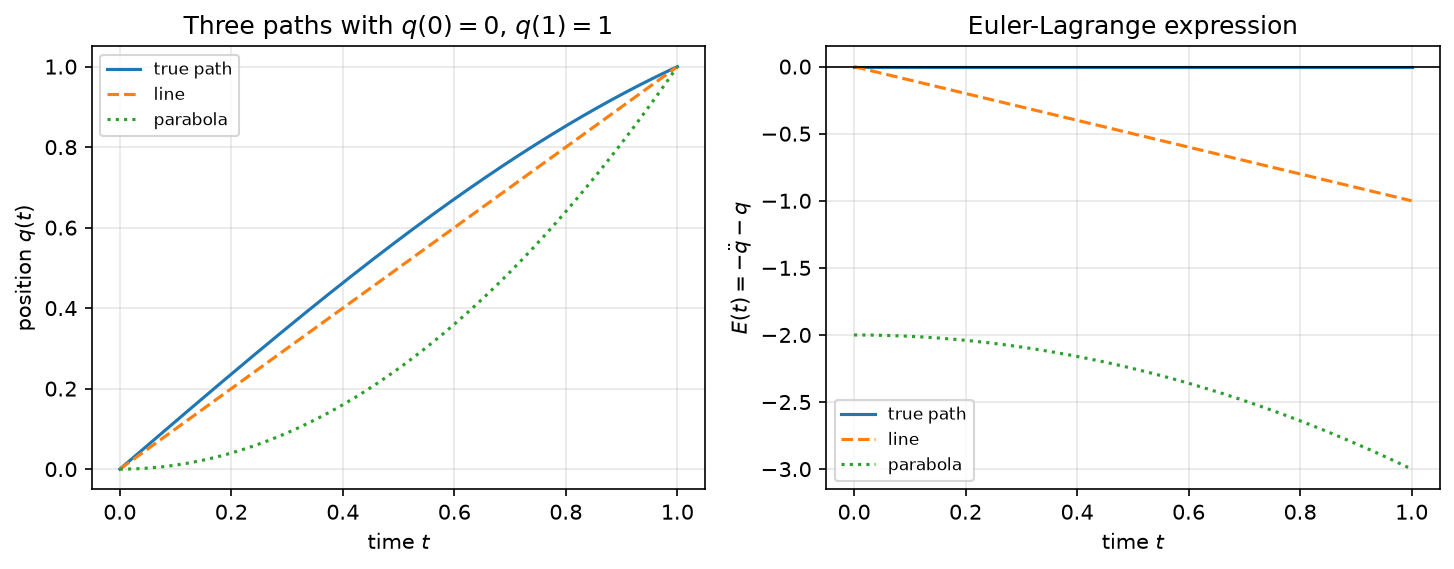

Figure 07d.2 saved as Revision/textbook/figures/07d_2_paths_and_residuals.png


In [6]:
times = np.linspace(0.0, 1.0, 201)
styles = {"true path": "-", "line": "--", "parabola": ":"}
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
for name, path in PATHS.items():
    left.plot(times, sp.lambdify(t, path)(times) * np.ones_like(times),
              styles[name], label=name)
    residual = sp.lambdify(t, E_of(path))(times) * np.ones_like(times)
    right.plot(times, residual, styles[name], label=name)
left.set_xlabel("time $t$")
left.set_ylabel("position $q(t)$")
left.set_title("Three paths with $q(0) = 0$, $q(1) = 1$")
left.legend(fontsize=8)
right.axhline(0.0, color="black", linewidth=0.8)
right.set_xlabel("time $t$")
right.set_ylabel("$E(t) = -\\ddot q - q$")
right.set_title("Euler-Lagrange expression")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "paths_and_residuals",
            "Left: three paths of the oscillator with the same end values $q(0) = "
            "0$ and $q(1) = 1$ against the time $t$ (pure numbers): the true path "
            "$\\sin t/\\sin 1$ (solid), the line $t$ (dashed) and the parabola "
            "$t^2$ (dotted); they look alike. Right: their Euler-Lagrange "
            "expressions $E(t) = -\\ddot q - q$, the amount by which the law of "
            "motion $\\ddot q = -q$ fails: zero for the true path at every time, "
            "$-t$ for the line, $-2 - t^2$ for the parabola. The first variation of "
            "the action is the integral of $E$ times the shape of the change.")

## 8. The fundamental lemma, seen with narrow bumps

Take the parabola, whose $E(t) = -2 - t^2$ is not zero, and a bump of half-width
$w$ centred at $t_0$:

$$\xi(t) = \cos^2\Big(\frac{\pi(t - t_0)}{2w}\Big)\ \text{for}\ |t - t_0| < w,
\qquad \xi(t) = 0\ \text{otherwise}.$$

The ratio $\int E\xi\,dt / \int\xi\,dt$ is an average of $E$ over the bump. As the
bump becomes narrower it tends to $E(t_0)$; so if $\int E\xi\,dt$ were zero for
every bump, $E(t_0)$ would be zero at every $t_0$. For this $E$ the error of the
average is exactly proportional to $w^2$: halving $w$ divides it by 4 (an average
over a symmetric bump removes the linear part of $E$ around $t_0$, and the
quadratic part leaves a term of size $w^2$). The next cell computes the integrals
with the trapezoidal rule on 200001 points (fine enough that its own error does not
matter), for $t_0 = 0.3, 0.5, 0.7$ and $w = 0.2, 0.1, 0.05, 0.025$, checks the
factor 4, and draws Figure 3.

t0 = 0.3: errors -5.228e-03, -1.307e-03, -3.267e-04, -8.168e-05; ratios 4.0000, 4.0000,
    4.0000
t0 = 0.5: errors -5.228e-03, -1.307e-03, -3.267e-04, -8.168e-05; ratios 4.0000, 4.0000,
    4.0000
t0 = 0.7: errors -5.228e-03, -1.307e-03, -3.267e-04, -8.168e-05; ratios 4.0000, 4.0000,
    4.0000
PASS the average of E over the bump tends to E(t0); halving w divides the error by 4


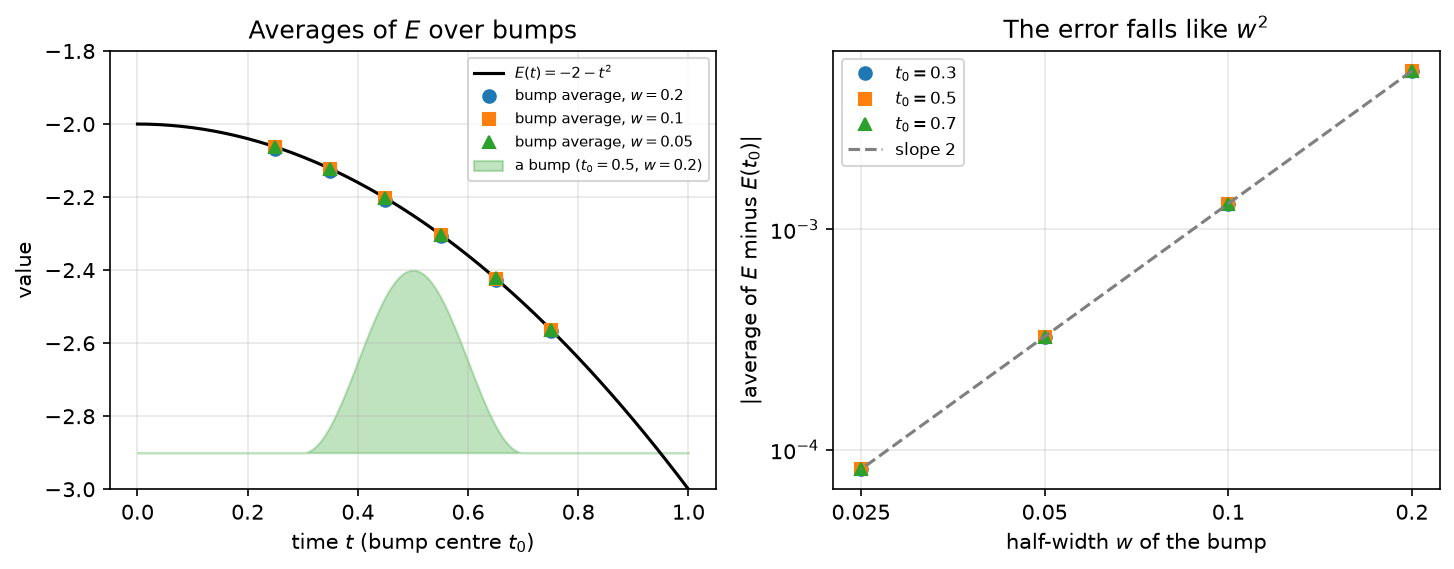

Figure 07d.3 saved as Revision/textbook/figures/07d_3_bump_lemma.png


In [7]:
grid = np.linspace(0.0, 1.0, 200001)  # fine grid for the integrals


def E_parabola(times_):
    return -2.0 - times_**2  # E(t) of the parabola path


def bump(times_, centre, width):
    """cos^2 bump of half-width width around centre, zero outside."""
    inside = np.abs(times_ - centre) < width
    return np.where(inside, np.cos(np.pi * (times_ - centre) / (2 * width)) ** 2, 0.0)


widths = [0.2, 0.1, 0.05, 0.025]
centres = [0.3, 0.5, 0.7]
errors = {}
for centre in centres:
    errors[centre] = []
    for width in widths:
        weight = bump(grid, centre, width)
        average = (np.trapezoid(E_parabola(grid) * weight, grid)
                   / np.trapezoid(weight, grid))
        errors[centre].append(average - E_parabola(centre))
    ratios = [errors[centre][i] / errors[centre][i + 1] for i in range(3)]
    say(f"t0 = {centre}: errors " + ", ".join(f"{e:+.3e}" for e in errors[centre])
        + "; ratios " + ", ".join(f"{r:.4f}" for r in ratios))
check(all(abs(errors[c][i] / errors[c][i + 1] - 4.0) < 1e-6
          for c in centres for i in range(3)),
      "the average of E over the bump tends to E(t0); halving w divides the error by 4")

fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
left.plot(times, E_parabola(times), color="black", label="$E(t) = -2 - t^2$")
for width, marker in zip(widths[:3], ["o", "s", "^"]):
    points = np.linspace(0.25, 0.75, 6)
    averages = [np.trapezoid(E_parabola(grid) * bump(grid, c, width), grid)
                / np.trapezoid(bump(grid, c, width), grid) for c in points]
    left.plot(points, averages, marker, label=f"bump average, $w = {width}$")
shown = bump(times, 0.5, 0.2)
left.fill_between(times, -2.9, -2.9 + 0.5 * shown, color="tab:green", alpha=0.3,
                  label="a bump ($t_0 = 0.5$, $w = 0.2$)")
left.set_ylim(-3.0, -1.8)
left.set_xlabel("time $t$ (bump centre $t_0$)")
left.set_ylabel("value")
left.set_title("Averages of $E$ over bumps")
left.legend(fontsize=7, loc="upper right")
for centre, marker in zip(centres, ["o", "s", "^"]):
    right.loglog(widths, np.abs(errors[centre]), marker, label=f"$t_0 = {centre}$")
reference = np.abs(errors[0.5][0]) * (np.array(widths) / widths[0]) ** 2
right.loglog(widths, reference, "--", color="grey", label="slope 2")
right.set_xticks(widths, [str(width) for width in widths])  # plain tick labels
right.minorticks_off()  # no unlabelled minor ticks
right.set_xlabel("half-width $w$ of the bump")
right.set_ylabel("|average of $E$ minus $E(t_0)$|")
right.set_title("The error falls like $w^2$")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "bump_lemma",
            "The fundamental lemma made visible, for the parabola path with $E(t) = "
            "-2 - t^2$ (black line). Left: the average of $E$ over a bump "
            "$\\cos^2(\\pi(t - t_0)/(2w))$ of half-width $w$ (one bump is shaded "
            "green at the bottom), plotted at its centre $t_0$ for $w = 0.2$, $0.1$, "
            "$0.05$; the averages approach the curve as the bumps narrow. Right: "
            "the distance of the average from $E(t_0)$ against $w$ on logarithmic "
            "axes for three centres; the points lie on a line of slope 2 (dashed): "
            "the error is proportional to $w^2$. A function whose integral against "
            "every bump vanishes must therefore vanish everywhere.")

## 9. The action on a grid

A computer stores a path as its values $q_0, q_1, \dots, q_N$ at the grid times
$t_n = nh$, $h = T/N$, and replaces the integral by a sum. With the velocity on
each step written as a difference quotient and the potential energy averaged over
the two ends of the step,

$$S_N = \sum_{n=0}^{N-1} h\Big[\frac12\Big(\frac{q_{n+1} - q_n}{h}\Big)^2 -
\frac{\omega^2}{4}\big(q_n^2 + q_{n+1}^2\big)\Big].$$

An inner value $q_n$ ($0 < n < N$) appears in two terms of the sum, the step that
ends at $t_n$ and the step that starts there. Differentiating, line by line:

$$\frac{\partial S_N}{\partial q_n} = h\Big[\frac{q_n - q_{n-1}}{h^2} -
\frac{q_{n+1} - q_n}{h^2} - \frac{\omega^2}{2}q_n - \frac{\omega^2}{2}q_n\Big]
= h\Big[-\frac{q_{n+1} - 2q_n + q_{n-1}}{h^2} - \omega^2q_n\Big].$$

The first equality takes the derivative of the two squares (chain rule: $\frac12
\cdot 2\cdot(q_n - q_{n-1})/h \cdot 1/h$ and $\frac12\cdot 2\cdot(q_{n+1} -
q_n)/h\cdot(-1/h)$) and of the two potential terms; the second collects. The
bracket is $E = -\ddot q - \omega^2q$ with $\ddot q$ replaced by the second
difference quotient. So "the action on the grid is stationary" means "the grid
version of the Euler-Lagrange equation holds at every inner point". The next cell
checks the derivative with sympy for $N = 5$ (symbols $h$, $\omega$, $q_0, \dots,
q_5$).

In [8]:
N5 = 5
h, w_sym = sp.symbols("h omega", positive=True)
qs = sp.symbols(f"q0:{N5 + 1}", real=True)  # q_0 .. q_5
S_grid = sum(h * (((qs[n + 1] - qs[n]) / h) ** 2 / 2
                  - w_sym**2 * (qs[n] ** 2 + qs[n + 1] ** 2) / 4) for n in range(N5))
grid_E = [h * (-(qs[n + 1] - 2 * qs[n] + qs[n - 1]) / h**2 - w_sym**2 * qs[n])
          for n in range(1, N5)]
check(all(sp.simplify(sp.diff(S_grid, qs[n]) - grid_E[n - 1]) == 0
          for n in range(1, N5)),
      "dS_N/dq_n = h (-(q_(n+1) - 2 q_n + q_(n-1))/h^2 - omega^2 q_n) for every "
      "inner n")

PASS dS_N/dq_n = h (-(q_(n+1) - 2 q_n + q_(n-1))/h^2 - omega^2 q_n) for every inner n


Setting all inner derivatives to zero gives $N - 1$ linear equations for the $N - 1$
inner values (the end values $q_0 = 0$ and $q_N = 1$ are fixed). The next cell
solves them with numpy for $N = 4, 8, \dots, 256$ and measures the largest
difference from the true path $\sin t/\sin 1$ at the grid times. Each doubling of
$N$ should divide the error by about 4: the error is proportional to $h^2$ (order
2), because the second difference quotient differs from $\ddot q$ by a term of
size $h^2$. The cell prints the errors and the observed orders
$\log_2(\text{error}_N/\text{error}_{2N})$, and draws Figure 4.

largest errors: N = 4: 4.089e-04, N = 8: 1.017e-04, N = 16: 2.582e-05, N = 32: 6.452e-06,
    N = 64: 1.613e-06, N = 128: 4.032e-07, N = 256: 1.008e-07
observed orders: 2.007, 1.978, 2.001, 2.000, 2.000, 2.000
PASS the stationary grid path converges to the true path with order 2


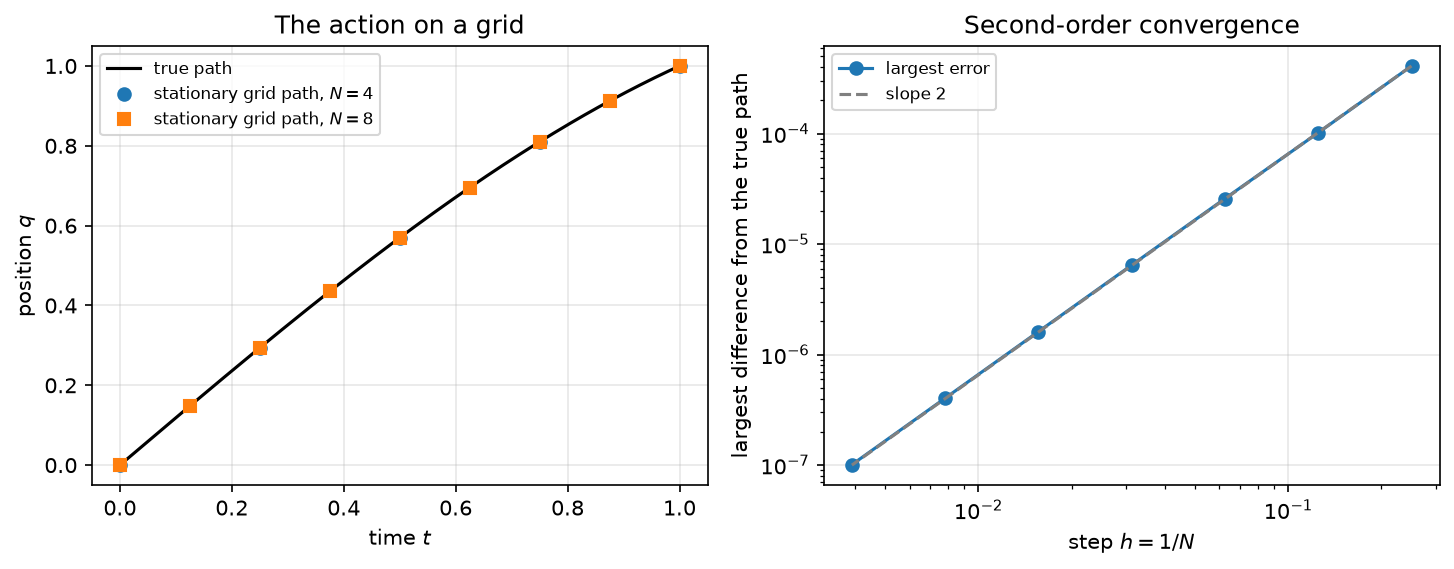

Figure 07d.4 saved as Revision/textbook/figures/07d_4_action_on_a_grid.png


In [9]:
def grid_path(N):
    """Solve the grid equations: returns the grid times and q_0 .. q_N."""
    step = 1.0 / N
    A = np.zeros((N - 1, N - 1))  # one row per inner point n = 1 .. N-1
    b = np.zeros(N - 1)
    for i in range(N - 1):
        A[i, i] = 2.0 / step**2 - 1.0  # from -(-2 q_n)/h^2 - omega^2 q_n
        if i > 0:
            A[i, i - 1] = -1.0 / step**2  # the neighbour q_(n-1)
        if i < N - 2:
            A[i, i + 1] = -1.0 / step**2  # the neighbour q_(n+1)
    b[-1] = 1.0 / step**2  # the known end value q_N = 1 moved to the right side
    inner = np.linalg.solve(A, b)
    return np.linspace(0.0, 1.0, N + 1), np.concatenate([[0.0], inner, [1.0]])


sizes = [4, 8, 16, 32, 64, 128, 256]
grid_errors = []
for N in sizes:
    nodes, values = grid_path(N)
    grid_errors.append(np.abs(values - np.sin(nodes) / np.sin(1.0)).max())
orders = [np.log2(grid_errors[i] / grid_errors[i + 1]) for i in range(len(sizes) - 1)]
say("largest errors: " + ", ".join(f"N = {N}: {e:.3e}"
                                   for N, e in zip(sizes, grid_errors)))
say("observed orders: " + ", ".join(f"{p:.3f}" for p in orders))
check(all(1.9 < p < 2.1 for p in orders),
      "the stationary grid path converges to the true path with order 2")

fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
left.plot(times, np.sin(times) / np.sin(1.0), color="black", label="true path")
for N, marker in ((4, "o"), (8, "s")):
    nodes, values = grid_path(N)
    left.plot(nodes, values, marker, label=f"stationary grid path, $N = {N}$")
left.set_xlabel("time $t$")
left.set_ylabel("position $q$")
left.set_title("The action on a grid")
left.legend(fontsize=8)
steps = 1.0 / np.array(sizes)
right.loglog(steps, grid_errors, "o-", label="largest error")
right.loglog(steps, grid_errors[0] * (steps / steps[0]) ** 2, "--", color="grey",
             label="slope 2")
right.set_xlabel("step $h = 1/N$")
right.set_ylabel("largest difference from the true path")
right.set_title("Second-order convergence")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "action_on_a_grid",
            "The action on a grid of times. Left: the path that makes the grid "
            "action $S_N$ stationary, for $N = 4$ (circles) and $N = 8$ (squares) "
            "steps, and the true path $\\sin t/\\sin 1$ (black line), against the "
            "time $t$ (pure numbers); already four steps follow the true path "
            "closely. Right: the largest difference between the grid path and the "
            "true path against the step $h = 1/N$, for $N = 4$ to $256$, on "
            "logarithmic axes; the points lie on a line of slope 2 (dashed): halving "
            "the step divides the error by 4.")

## 10. Energy is constant on the true path

The energy is $H = \dot q\,\partial L/\partial\dot q - L$; for the oscillator $H =
\dot q^2 - (\frac12\dot q^2 - \frac12\omega^2q^2) = \frac12\dot q^2 +
\frac12\omega^2q^2$, kinetic plus potential energy. Its time derivative, line by
line, for any path:

$$\frac{dH}{dt} = \ddot q\,\dot q + \omega^2q\,\dot q = \dot q\,(\ddot q +
\omega^2q) = -\dot q\,E .$$

The first equality is the chain rule; the second takes out the common factor
$\dot q$; the third uses $E = -\ddot q - \omega^2q$. So $H$ is constant on every
solution of $E = 0$ and changes on a path where $E \neq 0$ (unless $\dot q = 0$).
The next cell checks the identity for a general path, computes $dH/dt$ on the three
paths and draws Figure 5.

PASS dH/dt = -q' E for every path
true path: dH/dt = 0
line     : dH/dt = t
parabola : dH/dt = 2*t*(t**2 + 2)
PASS H is constant on the true path and changes on the two wrong paths
RESULT energy of the true path = 1/(2*sin(1)**2) = 0.706141


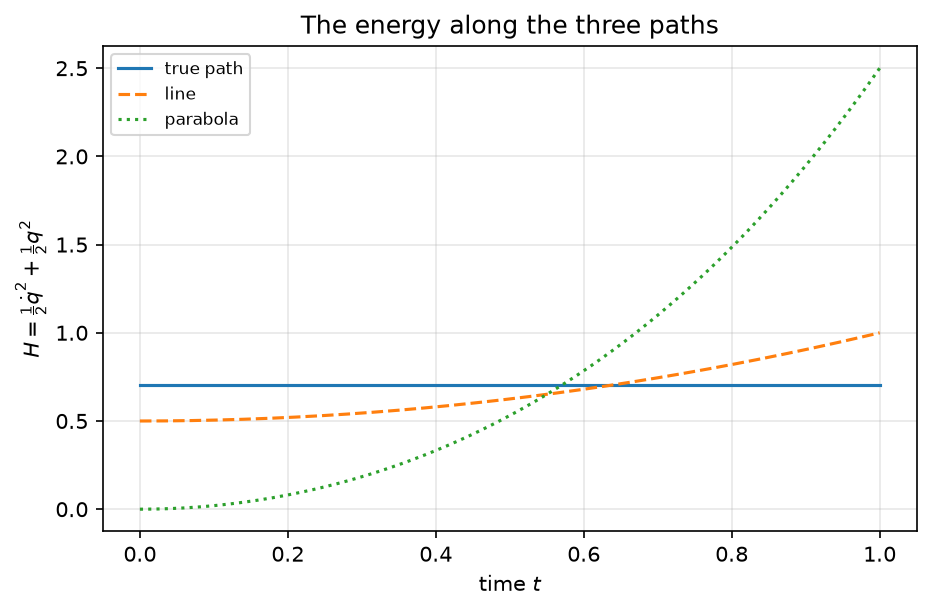

Figure 07d.5 saved as Revision/textbook/figures/07d_5_energy_along_paths.png


In [10]:
def energy(path):
    """H = (1/2) q'^2 + (1/2) omega^2 q^2 of a path."""
    return sp.diff(path, t) ** 2 / 2 + omega**2 * path**2 / 2


check(sp.simplify(sp.diff(energy(q), t) + sp.diff(q, t) * E_general) == 0,
      "dH/dt = -q' E for every path")
for name, path in PATHS.items():
    say(f"{name:9s}: dH/dt = {sp.simplify(sp.diff(energy(path), t))}")
check(sp.simplify(sp.diff(energy(PATHS["true path"]), t)) == 0
      and all(sp.simplify(sp.diff(energy(PATHS[name]), t)) != 0
              for name in ("line", "parabola")),
      "H is constant on the true path and changes on the two wrong paths")
true_energy = sp.simplify(energy(PATHS["true path"]))
report("energy of the true path", f"{true_energy} = {float(true_energy):.6f}")

fig, ax = plt.subplots()
for name, path in PATHS.items():
    values = sp.lambdify(t, energy(path))(times) * np.ones_like(times)
    ax.plot(times, values, styles[name], label=name)
ax.set_xlabel("time $t$")
ax.set_ylabel("$H = \\frac{1}{2}\\dot q^2 + \\frac{1}{2}q^2$")
ax.set_title("The energy along the three paths")
ax.legend(fontsize=8)
save_figure(fig, "energy_along_paths",
            "The energy $H = \\frac{1}{2}\\dot q^2 + \\frac{1}{2}\\omega^2q^2$ of the "
            "oscillator ($\\omega = 1$) along the three paths of Figure 07d.2, against "
            "the time $t$ (pure numbers). On the true path (solid) it is constant, "
            "$1/(2\\sin^2 1) \\approx 0.706$; on the line (dashed) and the "
            "parabola (dotted) it changes, because $dH/dt = -\\dot q\\,E$ and their "
            "Euler-Lagrange expression $E$ is not zero.")

## 11. A total derivative changes nothing

Add to $L$ the total derivative of a function $F(q, t)$, here $F = t\,q^3$:

$$L' = L + \frac{d}{dt}F(q(t), t) = L + q^3 + 3t\,q^2\dot q .$$

The action changes by $\int_0^1 \frac{dF}{dt}\,dt = F(q(1), 1) - F(q(0), 0)$, the
same number for every path with the given end values (here $1\cdot 1^3 - 0 = 1$).
A change that is the same for every path cannot change which path is stationary,
so $L'$ has the same Euler-Lagrange equation as $L$. In particular a Lagrangian
that is ONLY a total derivative, such as $\frac{d}{dt}(q^2) = 2q\dot q$, has the
Euler-Lagrange expression $2\dot q - \frac{d}{dt}(2q) = 0$ for every path: it
gives no equation at all. (Notebook 07c meets exactly this in the author's own
Lagrangian for a real anticommuting field.) The next cell checks all three
statements.

In [11]:
F = t * q**3  # F(q, t)
L = lagrangian(q, sp.diff(q, t))
E_changed = euler_lagrange(L + sp.diff(F, t), [q], t)[0]
check(sp.simplify(E_changed - E_general) == 0,
      "L + dF/dt with F = t q^3 has the same Euler-Lagrange expression as L")
E_pure = euler_lagrange(sp.diff(q**2, t), [q], t)[0]
check(E_pure == 0, "the pure total derivative d(q^2)/dt gives E = 0 for every path")
differences = [sp.simplify(sp.integrate(sp.diff(F.subs(q, path), t), (t, 0, 1)))
               for path in PATHS.values()]
say(f"S'[path] - S[path] for the three paths: {differences}")
check(all(d == 1 for d in differences),
      "the action changes by F(q(1), 1) - F(q(0), 0) = 1 for every path")

PASS L + dF/dt with F = t q^3 has the same Euler-Lagrange expression as L
PASS the pure total derivative d(q^2)/dt gives E = 0 for every path
S'[path] - S[path] for the three paths: [1, 1, 1]
PASS the action changes by F(q(1), 1) - F(q(0), 0) = 1 for every path


## 12. First-order Lagrangians

The Lagrangians of the two fields of this book contain the derivatives only to the
first power. Two small examples show what such Lagrangians do.

**Example A: two real variables.** $L_A = \frac12(q_0\dot q_1 - q_1\dot q_0) -
\frac12\omega(q_0^2 + q_1^2)$. For $q_0$: $\partial L_A/\partial q_0 = \frac12\dot
q_1 - \omega q_0$ and $\partial L_A/\partial\dot q_0 = -\frac12 q_1$, whose time
derivative is $-\frac12\dot q_1$; so $E_0 = \frac12\dot q_1 - \omega q_0 + \frac12
\dot q_1 = \dot q_1 - \omega q_0$. In the same way $E_1 = -\dot q_0 - \omega q_1$.
The equations $\dot q_1 = \omega q_0$, $\dot q_0 = -\omega q_1$ are of FIRST order:
the starting values alone fix the motion, $q_0 = \cos\omega t$, $q_1 = \sin\omega t$
for $q_0(0) = 1$, $q_1(0) = 0$, a rotation. The kinetic part is antisymmetric in
$(q_0, q_1)$ but not a total derivative for ordinary numbers; for anticommuting
numbers it would be one (Notebook 07a, section 17).

**Example B: one complex variable.** $\psi = (q_0 + iq_1)/\sqrt2$ and

$$L_B = \frac{i}{2}\big(\psi^*\dot\psi - \dot\psi^*\psi\big) - \omega\,\psi^*\psi .$$

Multiplying out with $\psi^* = (q_0 - iq_1)/\sqrt2$ gives $\psi^*\psi = \frac12(q_0^2
+ q_1^2)$ and $\psi^*\dot\psi - \dot\psi^*\psi = i(q_0\dot q_1 - q_1\dot q_0)$, so
$L_B = \frac12(q_1\dot q_0 - q_0\dot q_1) - \frac12\omega(q_0^2 + q_1^2)$: Example A
with the sense of rotation reversed. The two complex combinations can be varied AS
IF they were independent, because $(q_0, q_1) \to (\psi, \psi^*)$ is an invertible
linear change of variables; the Euler-Lagrange expressions combine in the same way,
$E_{\psi^*} = (E_{q_0} + iE_{q_1})/\sqrt2$. Varying $\psi^*$: $\partial L_B/\partial
\psi^* = \frac{i}{2}\dot\psi - \omega\psi$ and $\partial L_B/\partial\dot\psi^* =
-\frac{i}{2}\psi$, so $E_{\psi^*} = i\dot\psi - \omega\psi$ and $i\dot\psi =
\omega\psi$, with the solution $\psi = e^{-i\omega t}\psi(0)$. The Lagrangian of
the fields of this book has exactly this structure: $\psi$ becomes the column
$\Psi$, $\psi^*$ the row $\bar\Psi = \Psi^\dagger C$, and $\omega$ a matrix of
derivatives. The next cell checks every statement of the two examples, with
$\omega$ as a symbol.

In [12]:
w = sp.Symbol("omega", positive=True)
q0, q1 = sp.Function("q0")(t), sp.Function("q1")(t)
L_A = (q0 * sp.diff(q1, t) - q1 * sp.diff(q0, t)) / 2 - w * (q0**2 + q1**2) / 2
E_A = euler_lagrange(L_A, [q0, q1], t)
say(f"Example A: E_0 = {E_A[0]},  E_1 = {E_A[1]}")
check(sp.simplify(E_A[0] - (sp.diff(q1, t) - w * q0)) == 0
      and sp.simplify(E_A[1] - (-sp.diff(q0, t) - w * q1)) == 0,
      "Example A: E_0 = q1' - omega q0, E_1 = -q0' - omega q1")
rotation = {q0: sp.cos(w * t), q1: sp.sin(w * t)}
check(all(sp.simplify(e.subs(rotation).doit()) == 0 for e in E_A),
      "Example A: q0 = cos(omega t), q1 = sin(omega t) solves both equations")

psi, psi_star = sp.Function("psi")(t), sp.Function("psistar")(t)
L_B = (sp.I / 2 * (psi_star * sp.diff(psi, t) - sp.diff(psi_star, t) * psi)
       - w * psi_star * psi)
E_B = euler_lagrange(L_B, [psi_star, psi], t)  # vary psi* first, then psi
say(f"Example B: E_psi* = {E_B[0]},  E_psi = {E_B[1]}")
complex_form = {psi: (q0 + sp.I * q1) / sp.sqrt(2), psi_star: (q0 - sp.I * q1)
                / sp.sqrt(2)}
L_B_real = (q1 * sp.diff(q0, t) - q0 * sp.diff(q1, t)) / 2 - w * (q0**2 + q1**2) / 2
check(sp.simplify(sp.expand(L_B.subs(complex_form).doit() - L_B_real)) == 0,
      "Example B in real variables is Example A with the rotation reversed")
E_real = euler_lagrange(L_B_real, [q0, q1], t)
combined = E_B[0].subs(complex_form).doit() - (E_real[0] + sp.I * E_real[1]) / sp.sqrt(2)
check(sp.simplify(sp.expand(combined)) == 0,
      "E_psi* = (E_q0 + i E_q1)/sqrt(2): varying psi* is varying q0 and q1")
check(sp.simplify(E_B[0] - (sp.I * sp.diff(psi, t) - w * psi)) == 0
      and sp.simplify(E_B[0].subs(psi, sp.exp(-sp.I * w * t)).doit()) == 0,
      "Example B: i psi' = omega psi, solved by psi = exp(-i omega t)")

Example A: E_0 = -omega*q0(t) + Derivative(q1(t), t),  E_1 = -omega*q1(t) -
    Derivative(q0(t), t)
PASS Example A: E_0 = q1' - omega q0, E_1 = -q0' - omega q1
PASS Example A: q0 = cos(omega t), q1 = sin(omega t) solves both equations
Example B: E_psi* = -omega*psi(t) + I*Derivative(psi(t), t),  E_psi = -omega*psistar(t) -
    I*Derivative(psistar(t), t)
PASS Example B in real variables is Example A with the rotation reversed
PASS E_psi* = (E_q0 + i E_q1)/sqrt(2): varying psi* is varying q0 and q1
PASS Example B: i psi' = omega psi, solved by psi = exp(-i omega t)


Figure 6 draws the two motions in the $(q_0, q_1)$ plane for $\omega = 1$, starting
at $(1, 0)$: Example A turns counterclockwise, Example B clockwise; both stay on
the circle $q_0^2 + q_1^2 = 1$, because $|\psi|^2 = \frac12(q_0^2 + q_1^2)$ is
constant for $\psi = e^{-i\omega t}\psi(0)$.

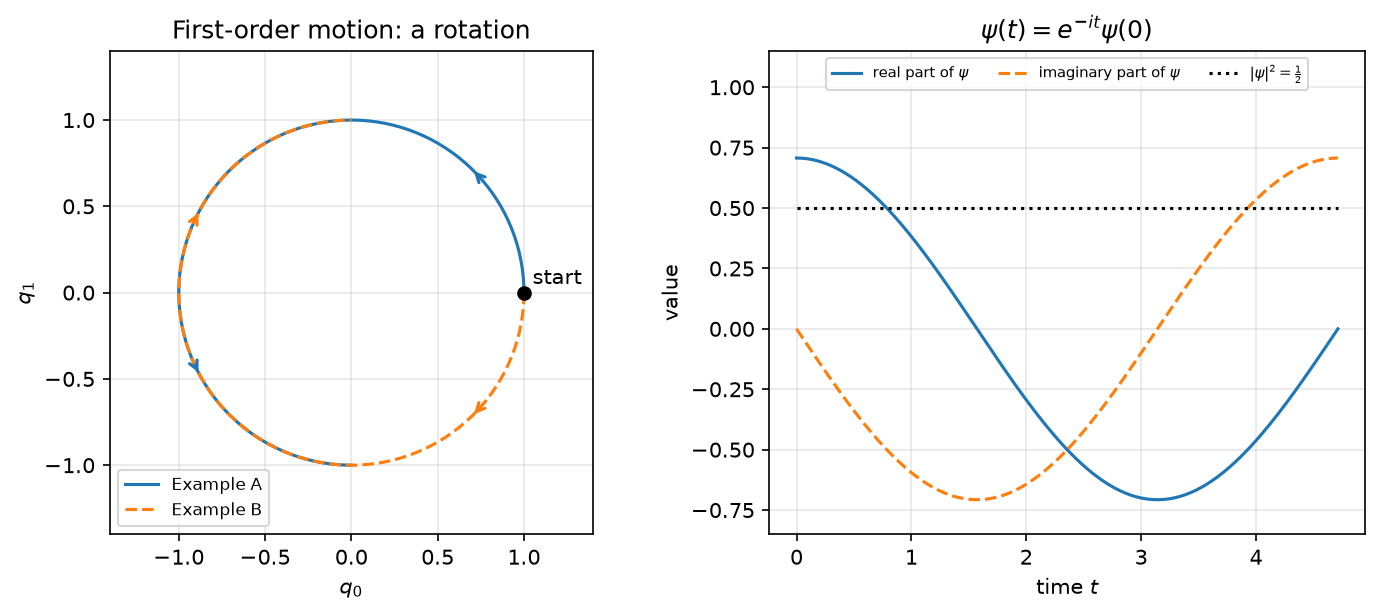

Figure 07d.6 saved as Revision/textbook/figures/07d_6_first_order_rotation.png


In [13]:
turn = np.linspace(0.0, 1.5 * np.pi, 200)  # times up to three quarters of a turn
fig, (left, right) = plt.subplots(1, 2, figsize=(9.6, 4.2))
for sense, label, style, colour in ((1.0, "Example A", "-", "tab:blue"),
                                    (-1.0, "Example B", "--", "tab:orange")):
    x, y = np.cos(turn), sense * np.sin(turn)
    left.plot(x, y, style, color=colour, label=label)
    for i in (30, 150):  # arrows that show the sense of the motion
        left.annotate("", xy=(x[i + 4], y[i + 4]), xytext=(x[i], y[i]),
                      arrowprops={"arrowstyle": "->", "lw": 1.5, "color": colour})
left.plot([1.0], [0.0], "ko")
left.text(1.05, 0.05, "start")
left.set_aspect("equal")
left.set_xlim(-1.4, 1.4)
left.set_ylim(-1.4, 1.4)
left.set_xlabel("$q_0$")
left.set_ylabel("$q_1$")
left.set_title("First-order motion: a rotation")
left.legend(fontsize=8, loc="lower left")
psi_values = np.exp(-1j * turn) / np.sqrt(2)  # psi(t) = exp(-i t) psi(0)
right.plot(turn, psi_values.real, label="real part of $\\psi$")
right.plot(turn, psi_values.imag, "--", label="imaginary part of $\\psi$")
right.plot(turn, np.abs(psi_values) ** 2, ":", color="black",
           label="$|\\psi|^2 = \\frac{1}{2}$")
right.set_xlabel("time $t$")
right.set_ylabel("value")
right.set_ylim(-0.85, 1.15)  # room for the legend above the curves
right.set_title("$\\psi(t) = e^{-it}\\psi(0)$")
right.legend(fontsize=7, loc="upper center", ncol=3)
fig.tight_layout()
save_figure(fig, "first_order_rotation",
            "First-order Lagrangians, with $\\omega = 1$. Left: the motion in the "
            "plane of the two real variables $(q_0, q_1)$, starting at $(1, 0)$ "
            "(dot), for three quarters of a turn: Example A (solid) turns "
            "counterclockwise, Example B, its complex form with the opposite sign "
            "of the kinetic term, turns clockwise (dashed); the arrows show the "
            "sense. Right: the complex variable $\\psi = (q_0 + iq_1)/\\sqrt{2}$ "
            "of Example B against the time $t$: real part $\\cos t/\\sqrt{2}$, "
            "imaginary part $-\\sin t/\\sqrt{2}$, and the constant $|\\psi|^2 = "
            "\\frac{1}{2}$.")

## 13. A field of one space direction and time

A field $\phi(x_1, x_4)$ of a 3-space coordinate $x_1$ and the time $x_4$ has, in
the flat version of the author's signature ($\eta_{11} = +1$, $\eta_{44} = -1$),
the Lagrangian density

$$\mathcal{L} = -\frac12\big(\eta^{11}(\partial_1\phi)^2 + \eta^{44}(\partial_4
\phi)^2\big) - \frac12 m^2\phi^2 = \frac12(\partial_4\phi)^2 - \frac12(\partial_1
\phi)^2 - \frac12 m^2\phi^2,$$

kinetic minus potential energy again, with a gradient energy along $x_1$. The
Euler-Lagrange expression has one derivative term per coordinate, line by line:

$$E = \frac{\partial\mathcal{L}}{\partial\phi} - \partial_1\frac{\partial
\mathcal{L}}{\partial(\partial_1\phi)} - \partial_4\frac{\partial\mathcal{L}}
{\partial(\partial_4\phi)} = -m^2\phi - \partial_1(-\partial_1\phi) -
\partial_4(\partial_4\phi) = \partial_1^2\phi - \partial_4^2\phi - m^2\phi .$$

The first equality is the field version of section 4 (one integration by parts per
coordinate); the second inserts the three partial derivatives of $\mathcal{L}$;
the third simplifies. So $\partial_4^2\phi = \partial_1^2\phi - m^2\phi$, the wave
equation with a mass (the Klein-Gordon equation). A plane wave $\cos(kx_1)\cos(
\omega x_4)$ solves it exactly when $\omega^2 = m^2 + k^2$: it oscillates in time.

The next cell defines `field_euler_lagrange` (the same recipe as `euler_lagrange`,
with one derivative symbol per coordinate), checks the equation and the plane
wave, and checks the grid version: on a grid with steps $h_1$, $h_4$ the field
action is a sum over cells, and its derivative with respect to an inner value
$\phi_{ij}$ is $h_1h_4$ times the grid Euler-Lagrange expression (second difference
quotients in place of $\partial_1^2$ and $\partial_4^2$). The derivative is computed
numerically by the central difference $(S(\phi_{ij} + \delta) - S(\phi_{ij} -
\delta))/(2\delta)$, which is exact (up to rounding) for an action that is quadratic
in $\phi$, for a field of random values (fixed seed) on a grid of 7 by 6 points.

In [14]:
x1, x4, x5 = sp.symbols("x1 x4 x5", real=True)
m = sp.Symbol("m", positive=True)


def field_euler_lagrange(L, field, coordinates):
    """dL/dphi - sum over the coordinates of d/dx dL/d(dphi/dx)."""
    value = sp.Symbol("P")  # stands for phi
    slopes = [sp.Symbol(f"D{i}") for i in range(len(coordinates))]  # dphi/dx
    plain = L
    for x, slope in zip(coordinates, slopes):
        plain = plain.subs(sp.diff(field, x), slope)
    plain = plain.subs(field, value)
    back = {**{s: sp.diff(field, x) for x, s in zip(coordinates, slopes)},
            value: field}
    result = sp.diff(plain, value).subs(back)
    for x, slope in zip(coordinates, slopes):
        result -= sp.diff(sp.diff(plain, slope).subs(back), x)
    return sp.expand(result)


ETA = {x1: 1, x4: -1, x5: -1}  # the author's signs: x1 space-like, x4, x5 time-like
phi = sp.Function("phi")(x1, x4)
L_space = (-(ETA[x1] * sp.diff(phi, x1) ** 2 + ETA[x4] * sp.diff(phi, x4) ** 2) / 2
           - m**2 * phi**2 / 2)
E_space = field_euler_lagrange(L_space, phi, [x1, x4])
say(f"E = {E_space}")
check(sp.simplify(E_space - (sp.diff(phi, x1, 2) - sp.diff(phi, x4, 2)
                             - m**2 * phi)) == 0,
      "space and time: E = d1^2 phi - d4^2 phi - m^2 phi (Klein-Gordon)")
k, frequency = sp.symbols("k omega_k", positive=True)
wave = sp.cos(k * x1) * sp.cos(frequency * x4)
on_wave = E_space.subs(phi, wave).doit()
check(sp.simplify(on_wave.subs(frequency, sp.sqrt(m**2 + k**2))) == 0
      and sp.simplify(on_wave.subs(frequency, k)) != 0,
      "cos(k x1) cos(omega x4) solves it exactly when omega^2 = m^2 + k^2")

rng = np.random.default_rng(12345)  # random numbers with a fixed seed
h1, h4, mass = 0.3, 0.2, 1.5  # grid steps and the mass
field_values = rng.normal(size=(7, 6))  # phi_ij: i along x1, j along x4


def grid_action(f):
    """The field action on the grid: a sum over the cells."""
    d4 = (f[:-1, 1:] - f[:-1, :-1]) / h4  # time differences
    d1 = (f[1:, :-1] - f[:-1, :-1]) / h1  # space differences
    return h1 * h4 * np.sum(d4**2 / 2 - d1**2 / 2 - mass**2 * f[:-1, :-1] ** 2 / 2)


largest = 0.0
delta = 1e-3
for i in range(1, 6):
    for j in range(1, 5):
        plus, minus = field_values.copy(), field_values.copy()
        plus[i, j] += delta
        minus[i, j] -= delta
        numeric = (grid_action(plus) - grid_action(minus)) / (2 * delta)
        f_ = field_values  # a short name for the formula below
        expected = h1 * h4 * (
            (f_[i + 1, j] - 2 * f_[i, j] + f_[i - 1, j]) / h1**2  # space part
            - (f_[i, j + 1] - 2 * f_[i, j] + f_[i, j - 1]) / h4**2  # time part
            - mass**2 * f_[i, j])
        largest = max(largest, abs(numeric - expected))
say("largest difference over the 20 inner points is below 1e-9: "
    f"{largest < 1e-9}")
check(largest < 1e-9, "on the grid: dS/dphi_ij = h1 h4 times the grid "
      "Euler-Lagrange expression at every inner point")

E = -m**2*phi(x1, x4) + Derivative(phi(x1, x4), (x1, 2)) - Derivative(phi(x1, x4), (x4,
    2))
PASS space and time: E = d1^2 phi - d4^2 phi - m^2 phi (Klein-Gordon)
PASS cos(k x1) cos(omega x4) solves it exactly when omega^2 = m^2 + k^2
largest difference over the 20 inner points is below 1e-9: True
PASS on the grid: dS/dphi_ij = h1 h4 times the grid Euler-Lagrange expression at every
    inner point


## 14. A field of one EXTRA time and time

Now replace the space coordinate $x_1$ by the extra time $x_5$. The author's
signature makes $x_5$ time-like, $\eta_{55} = -1$, and the same recipe gives

$$\mathcal{L} = \frac12(\partial_4\phi)^2 + \frac12(\partial_5\phi)^2 - \frac12
m^2\phi^2,\qquad E = -\partial_5^2\phi - \partial_4^2\phi - m^2\phi .$$

The only change is the sign of the $x_5$ term. Try $\phi = \cos(kx_5)\,P(x_4)$:
then $\partial_5^2\phi = -k^2\phi$, and $E = 0$ becomes

$$P'' = (k^2 - m^2)\,P .$$

For $k < m$ the solutions oscillate, but for $k > m$ they are $\cosh(\kappa x_4)$
and $\sinh(\kappa x_4)$ with $\kappa = \sqrt{k^2 - m^2}$: they GROW exponentially,
at a rate that becomes as large as we like when $k$ grows. A wave along a space
direction lowers nothing (its $\omega^2 = m^2 + k^2$); a wave along an extra time
lowers $\omega^2 = m^2 - k^2$ below zero.

The fields of this book obey a first-order equation; in flat space, multiplying it
by the same operator once more gives this second-order equation for every one of
the 16 components, because $(\gamma^{(a)}k_a)^2 = (\eta^{ab}k_ak_b)\,I_{16}$ (the
Clifford relation). The Revision record finds the same growth rate for the
16-component field. The next cell checks the extra-time field equation and its
growing solution, checks the Clifford square with the author's gammas, and reads
the growth-rate formula from the Revision scope record and compares it, for a
momentum along $x_5$ only, with $\kappa = \sqrt{k^2 - m^2}$.

In [15]:
phi5 = sp.Function("phi")(x5, x4)
L_extra = (-(ETA[x5] * sp.diff(phi5, x5) ** 2 + ETA[x4] * sp.diff(phi5, x4) ** 2) / 2
           - m**2 * phi5**2 / 2)
E_extra = field_euler_lagrange(L_extra, phi5, [x5, x4])
say(f"E = {E_extra}")
check(sp.simplify(E_extra - (-sp.diff(phi5, x5, 2) - sp.diff(phi5, x4, 2)
                             - m**2 * phi5)) == 0,
      "extra time and time: E = -d5^2 phi - d4^2 phi - m^2 phi")
kappa = sp.Symbol("kappa", positive=True)
growing = sp.cos(k * x5) * sp.cosh(kappa * x4)
check(sp.simplify(E_extra.subs(phi5, growing).doit()
                  .subs(kappa, sp.sqrt(k**2 - m**2))) == 0,
      "cos(k x5) cosh(kappa x4) solves it with kappa^2 = k^2 - m^2: growth for k > m")

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
G = [sp.Matrix(g) for g in fixture["gamma"]]  # gamma^(x1) .. gamma^(x8)
signs = [1, 1, 1, -1, -1, -1, -1, 1]  # eta in the order x1 .. x8
ks = sp.symbols("k1:9", real=True)  # a frame momentum with 8 components
slash = sum((ks[a] * G[a] for a in range(8)), sp.zeros(16, 16))  # gamma^(a) k_a
norm = sum(signs[a] * ks[a] ** 2 for a in range(8))  # eta^ab k_a k_b
check((slash * slash - norm * sp.eye(16)).applyfunc(sp.expand) == sp.zeros(16, 16),
      "(gamma^a k_a)^2 = (k1^2 + k2^2 + k3^2 - k4^2 - k5^2 - k6^2 - k7^2 + k8^2) I16",
      record=reproduces("Revision/theory/reports/python-field-theory.json",
                        "clifford_relations"))

SCOPE = "Revision/theory/reports/python-scope.json"
detail = revision_check(SCOPE, "extra_time_growth_rates_unbounded")["detail"]
formula = re.search(r"Im E = (sqrt\([^)]*\))", detail).group(1)  # the record's rate
say(f"growth rate in the record: {formula}")
K = sp.Symbol("K", positive=True)
rate = sp.sympify(formula, locals={"K": K, "m": m,
                                   **{f"k{i}": sp.Symbol(f"k{i}") for i in range(9)}})
along_x5 = rate.subs({sp.Symbol(f"k{i}"): 0 for i in (1, 2, 3, 8)}).subs(K, k)
check(sp.simplify(along_x5 - sp.sqrt(k**2 - m**2)) == 0,
      "the record's rate for a momentum along x5 only is sqrt(k^2 - m^2) = kappa",
      record=reproduces(SCOPE, "extra_time_growth_rates_unbounded"))

E = -m**2*phi(x5, x4) - Derivative(phi(x5, x4), (x4, 2)) - Derivative(phi(x5, x4), (x5,
    2))
PASS extra time and time: E = -d5^2 phi - d4^2 phi - m^2 phi
PASS cos(k x5) cosh(kappa x4) solves it with kappa^2 = k^2 - m^2: growth for k > m
PASS (gamma^a k_a)^2 = (k1^2 + k2^2 + k3^2 - k4^2 - k5^2 - k6^2 - k7^2 + k8^2) I16
     reproduces Revision/theory/reports/python-field-theory.json, check
    clifford_relations
growth rate in the record: sqrt(K**2 - k1**2 - k2**2 - k3**2 - k8**2 - m**2)
PASS the record's rate for a momentum along x5 only is sqrt(k^2 - m^2) = kappa
     reproduces Revision/theory/reports/python-scope.json, check
    extra_time_growth_rates_unbounded


Figure 7 shows the two plane waves for $m = 1$ and $k = 2$ as maps over a
coordinate (horizontal) and the time $x_4$ (vertical): along the space direction
$x_1$ the field oscillates in time with $\omega = \sqrt5$; along the extra time
$x_5$ it grows like $\cosh(\sqrt3\,x_4)$. Figure 8 shows the dispersion relations
and the growth rate against the wave number.

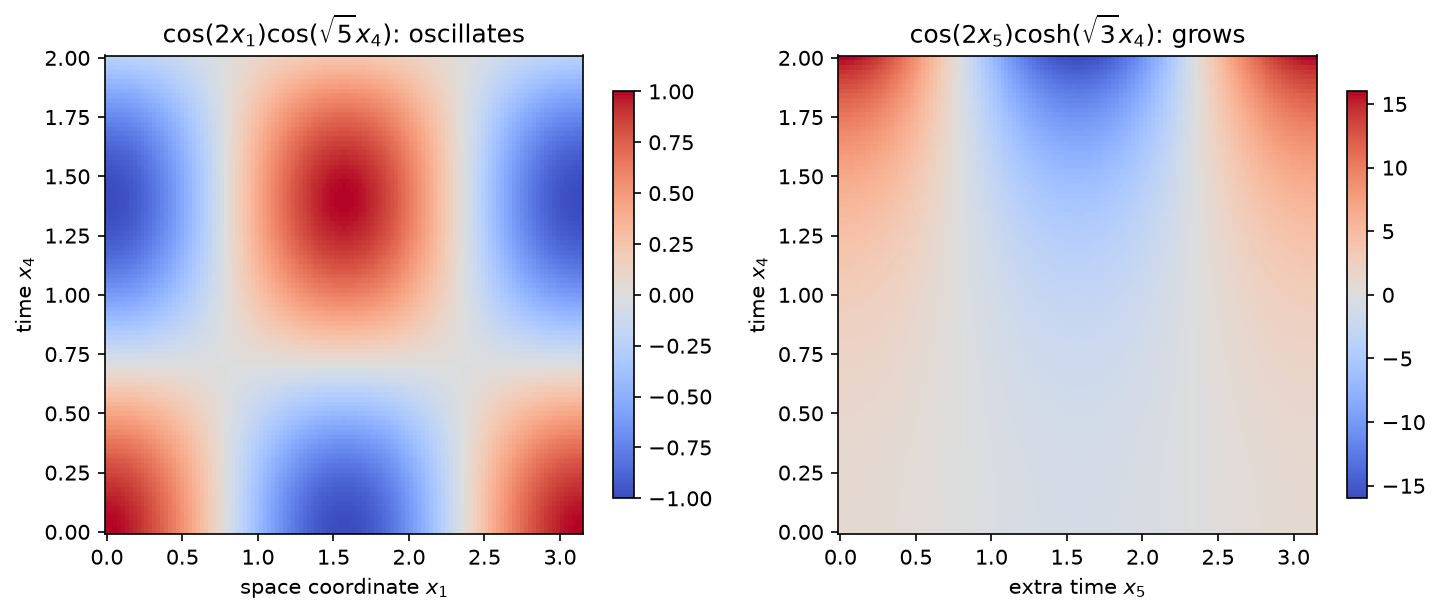

Figure 07d.7 saved as Revision/textbook/figures/07d_7_space_and_extra_time.png


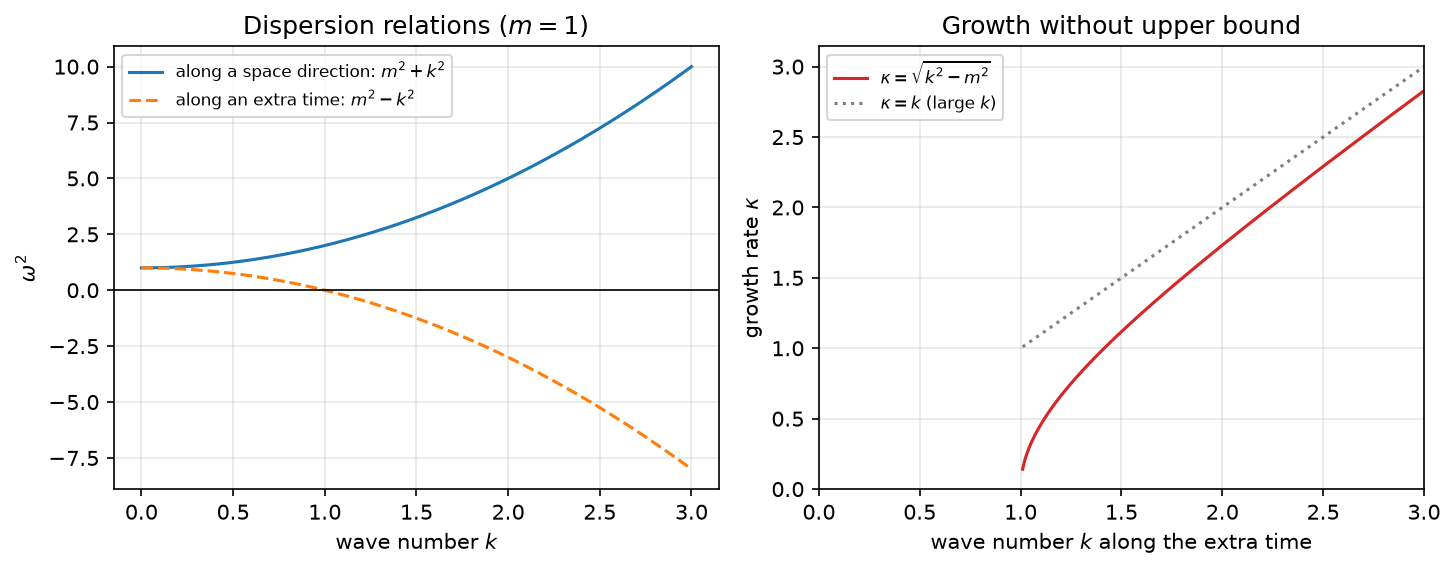

Figure 07d.8 saved as Revision/textbook/figures/07d_8_dispersion.png


In [16]:
coordinate = np.linspace(0.0, 2 * np.pi / 2.0, 121)  # one wavelength for k = 2
clock = np.linspace(0.0, 2.0, 101)  # the time x4 from 0 to 2
X, Y = np.meshgrid(coordinate, clock)
space_wave = np.cos(2.0 * X) * np.cos(np.sqrt(5.0) * Y)
extra_wave = np.cos(2.0 * X) * np.cosh(np.sqrt(3.0) * Y)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 4.2))
image = left.pcolormesh(X, Y, space_wave, cmap="coolwarm", vmin=-1, vmax=1,
                        shading="auto")
fig.colorbar(image, ax=left, shrink=0.85)
left.set_xlabel("space coordinate $x_1$")
left.set_ylabel("time $x_4$")
left.set_title("$\\cos(2x_1)\\cos(\\sqrt{5}x_4)$: oscillates")
limit = float(np.cosh(np.sqrt(3.0) * 2.0))
image = right.pcolormesh(X, Y, extra_wave, cmap="coolwarm", vmin=-limit, vmax=limit,
                         shading="auto")
fig.colorbar(image, ax=right, shrink=0.85)
right.set_xlabel("extra time $x_5$")
right.set_ylabel("time $x_4$")
right.set_title("$\\cos(2x_5)\\cosh(\\sqrt{3}x_4)$: grows")
for ax in (left, right):
    ax.grid(False)
fig.tight_layout()
save_figure(fig, "space_and_extra_time",
            "Two exact solutions of the field equation with mass $m = 1$ and wave "
            "number $k = 2$, as colour maps over one wavelength of a coordinate "
            "(horizontal) and the time $x_4$ from 0 to 2 (vertical), pure numbers; "
            "red positive, blue negative. Left: a wave along the space direction "
            "$x_1$, $\\cos(2x_1)\\cos(\\sqrt{5}x_4)$, which oscillates in time "
            "between $-1$ and $1$. Right: a wave along the extra time $x_5$, "
            "$\\cos(2x_5)\\cosh(\\sqrt{3}x_4)$, which grows; its colour scale "
            "reaches $\\cosh(2\\sqrt{3}) \\approx 16$. The only difference in the "
            "Lagrangian is the sign of the term of the second coordinate.")

numbers = np.linspace(0.0, 3.0, 301)  # the wave number k, with m = 1
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.9))
left.plot(numbers, 1.0 + numbers**2, label="along a space direction: $m^2 + k^2$")
left.plot(numbers, 1.0 - numbers**2, "--",
          label="along an extra time: $m^2 - k^2$")
left.axhline(0.0, color="black", linewidth=0.8)
left.set_xlabel("wave number $k$")
left.set_ylabel("$\\omega^2$")
left.set_title("Dispersion relations ($m = 1$)")
left.legend(fontsize=8)
above = numbers[numbers > 1.0]
right.plot(above, np.sqrt(above**2 - 1.0), color="tab:red",
           label="$\\kappa = \\sqrt{k^2 - m^2}$")
right.plot(above, above, ":", color="grey", label="$\\kappa = k$ (large $k$)")
right.set_xlim(0.0, 3.0)
right.set_xlabel("wave number $k$ along the extra time")
right.set_ylabel("growth rate $\\kappa$")
right.set_title("Growth without upper bound")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "dispersion",
            "Left: the square $\\omega^2$ of the angular frequency of a plane wave "
            "against its wave number $k$ (pure numbers, mass $m = 1$), for a wave "
            "along a space direction ($m^2 + k^2$, always positive: oscillation) "
            "and along an extra time ($m^2 - k^2$, negative for $k > m$). Right: "
            "for $k > m$ the wave grows like $e^{\\kappa x_4}$ with the rate "
            "$\\kappa = \\sqrt{k^2 - m^2}$ (red), which approaches $k$ (dotted) and "
            "has no upper bound; the Revision record finds the same rate for the "
            "16-component field.")

## 15. The last check

The last cell checks that the eight figure files exist and prints the number of
checks that passed.

In [17]:
names = ["action_versus_epsilon", "paths_and_residuals", "bump_lemma",
         "action_on_a_grid", "energy_along_paths", "first_order_rotation",
         "space_and_extra_time", "dispersion"]
files = [f"{FIGURE_FOLDER}/07d_{k_}_{name}.png" for k_, name in enumerate(names, 1)]
check(all(output_file(path).is_file() for path in files),
      "all 8 figure files of this notebook exist")
all_checks_passed()

PASS all 8 figure files of this notebook exist
ALL 30 CHECKS PASSED (notebook 07d)


## 16. What this notebook showed

- The action $S[q] = \int L\,dt$ of a path changed by $\epsilon\xi$ is, for the
  oscillator, a quadratic polynomial in $\epsilon$; its slope at $\epsilon = 0$ is
  exactly zero for the true path $\sin t/\sin 1$ and not zero for the wrong paths
  $t$ and $t^2$. For short times the true path is a minimum, for times longer than
  $\pi/\omega$ only a saddle: the principle is one of STATIONARY action.
- Integration by parts turns the slope into $\int E\,\xi\,dt$ with the
  Euler-Lagrange expression $E = \partial L/\partial q - \frac{d}{dt}\partial L/
  \partial\dot q$, plus a boundary term that vanishes when $\xi$ vanishes at the
  ends; narrow bumps show that $\int E\xi\,dt = 0$ for all $\xi$ forces $E = 0$.
- On a grid of times the stationary action gives the grid Euler-Lagrange equation,
  and its solution approaches the true path with an error proportional to $h^2$.
- The energy $\frac12\dot q^2 + \frac12\omega^2q^2$ is constant exactly on the
  solutions ($dH/dt = -\dot q\,E$).
- A total derivative added to $L$ changes no equation, and a Lagrangian that is a
  total derivative gives none.
- First-order Lagrangians give first-order equations; a complex variable and its
  conjugate may be varied as if independent, and $\frac{i}{2}(\psi^*\dot\psi -
  \dot\psi^*\psi) - \omega\psi^*\psi$ gives $i\dot\psi = \omega\psi$: the structure
  of the Lagrangians of the fields of this book.
- For fields, one derivative term per coordinate appears; along a space direction
  the field oscillates ($\omega^2 = m^2 + k^2$), along an extra time it grows at the
  rate $\sqrt{k^2 - m^2}$, without upper bound: the same rate as in the Revision
  record for the 16-component field.